<a href="https://colab.research.google.com/github/jaizunT/deep_learning/blob/main/hw11/scaling_laws.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaling Laws

A common question in neural network training is, how should I select my hyperparameters? While a proper hyperparameter sweep will always provide the best answer, sweeps can become impractical especially at larger network sizes. In this case, the field has converged to two main options: 1), copy what a previous project used (which is always a good starting point), or 2) derive *scaling laws* which can predict what the best hyperparameters will be.

In this homework question, we will derive a simple scaling law for the optimal learning rate under varying batch sizes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch


First, let's consider the case of a simple least-squares gradient descent problem. We will define our dataset using a randomly-sampled ground truth linear mapping, and our training samples will be augmented by some amount of noise. For this homework, we will focus on the question of **how should learning rate scale with batch size?**

In [ ]:
np.random.seed(0)
N = 10000 # number of data samples
D = 16  # input dimension
sigma = 5 # noise std

X_train = np.random.randn(10_000,D) # gaussian inputs for training data
X_test = np.random.randn(1_000,D) # gaussian inputs for test data
w_true = np.random.randn(D,D) # ground truth weight
y_train = X_train @ w_true + sigma * np.random.randn(10_000,D) # noisy outputs training data
y_test = X_test @ w_true + sigma * np.random.randn(1_000,D) # noisy outputs test data

def analytical_solution(X, y, n):
    pseudo_inv_X = np.linalg.pinv(X[:n, :], rcond=0) # pseudo-inverse of X
    w_analytical = pseudo_inv_X @ y[:n, :] # analytical solution
    return w_analytical

def compute_mse(X, y, w):
    y_pred = X @ w # predicted outputs
    mse = np.mean((y - y_pred)**2) # mean squared error
    return mse

def compute_losses(X_train, y_train, X_test, y_test, N):
    train_losses = []
    test_losses = []
    ns = list(range(1, N+1))
    for n in ns:
        w_analytical = analytical_solution(X_train, y_train, n)
        train_mse = compute_mse(X_train, y_train, w_analytical)
        test_mse = compute_mse(X_test, y_test, w_analytical)
        train_losses.append(train_mse)
        test_losses.append(test_mse)
    return ns, train_losses, test_losses

In [ ]:
def run_sgd(iters, batch_size, lr):
    np.random.seed(0)
    w_init = np.random.randn(D, D)

    test_sgd_mse = []
    train_sgd_mse = []

    w = w_init
    for i in range(iters):
        idx = np.random.randint(0, N, batch_size)
        x = X_train[idx]
        y = y_train[idx]
        grad = (2/batch_size) * (x.T @ x @ w - x.T @ y)  # shape (D, 1)

        w = w - lr * grad
        train_mse = compute_mse(x, y, w)
        test_mse = compute_mse(X_test, y_test, w)
        test_sgd_mse.append(test_mse)
        train_sgd_mse.append(train_mse)

    return w, train_sgd_mse, test_sgd_mse

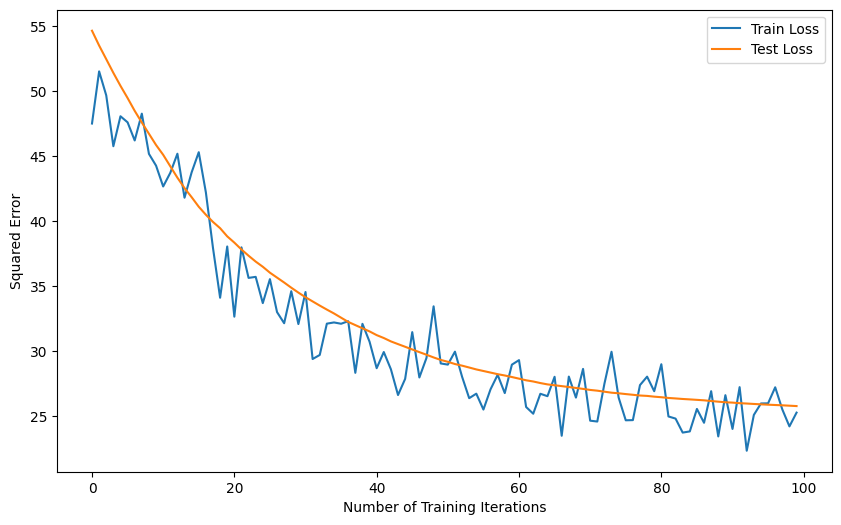

In [ ]:
w, train_sgd_mse, test_sgd_mse = run_sgd(iters=100, batch_size=32, lr=0.01)

plt.figure(figsize=(10, 6))
plt.plot(train_sgd_mse, label='Train Loss')
plt.plot(test_sgd_mse, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel('Squared Error')
plt.legend()

We can plot the above curves on log-linear scale while subtracting off the irreducible error of $\sigma^2$ to see the linear decay of the squared error. This allows for a better view of the convergence rate.

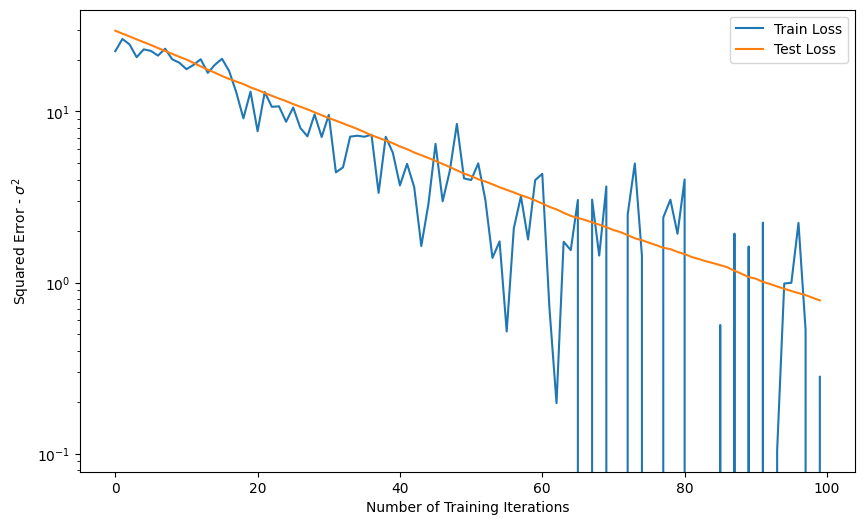

In [ ]:
plt.figure(figsize=(10, 6))
train_sgd_mse_res = [mse - sigma**2 for mse in train_sgd_mse]
test_sgd_mse_res = [mse - sigma**2 for mse in test_sgd_mse]
plt.plot(train_sgd_mse_res, label='Train Loss')
plt.plot(test_sgd_mse_res, label='Test Loss')
plt.yscale('log')
plt.xlabel('Number of Training Iterations')
plt.ylabel(r'Squared Error - $\sigma^2$')
plt.legend()

## Q1: Scaling law for least-squares SGD.

Perform a sweep over learning rates. Consider the batch sizes between [2, 4, 16, 64, 256, 1024, 2048], and sweep over learning rates logarithmically with a resolution of $1.25$. For example, you should consider the learning rate of $0.001, 0.001 * 1.25, 0.001 * 1.25^2$, etc. **Make sure your learning rate sweep covers the optimal LR for each batch size (e.g. your optimal LR should not be at the boundary of your learning rate intervals.) You should be able to sweep around ~32 learning rates per batch size.

- Plot your learning rates on the same graph, with each batchsize as a different curve. You curve should resemble the example provided.
- Plot the relationship between batch size (x-axis) and the optimal learning rate (y-axis). What function does this resemble?

Hint: Many runs will result in very high losses if the iteration diverges. It will help to clip the losses to some ceiling value before plotting.

Hint 2: You may find that some batch sizes have a wide basin of optimal learning rates that perform roughly equivalently. In this case, it may help to plot the *average* learning rate that is within X% of the optimal. This can make the relationship more clear.

![fig-example](https://github.com/Berkeley-CS182/cs182fa25_public/blob/main/hw11/code/fig-example.png?raw=1)

Running for batch size: 2
Running for batch size: 4
Running for batch size: 16
Running for batch size: 64
Running for batch size: 256
Running for batch size: 1024
Running for batch size: 2048


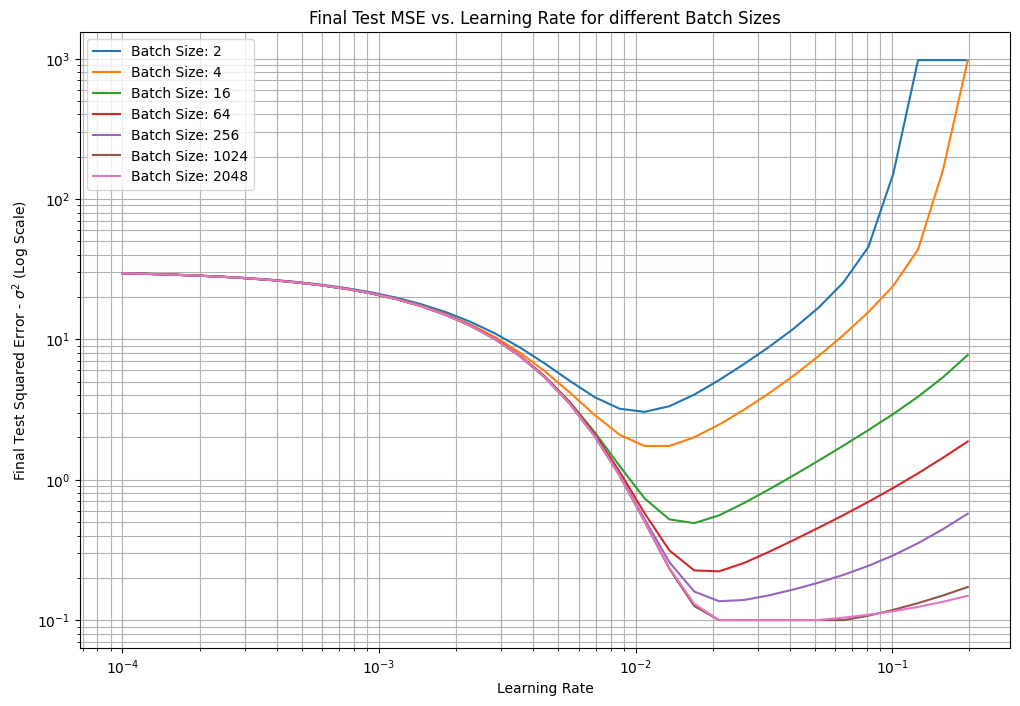

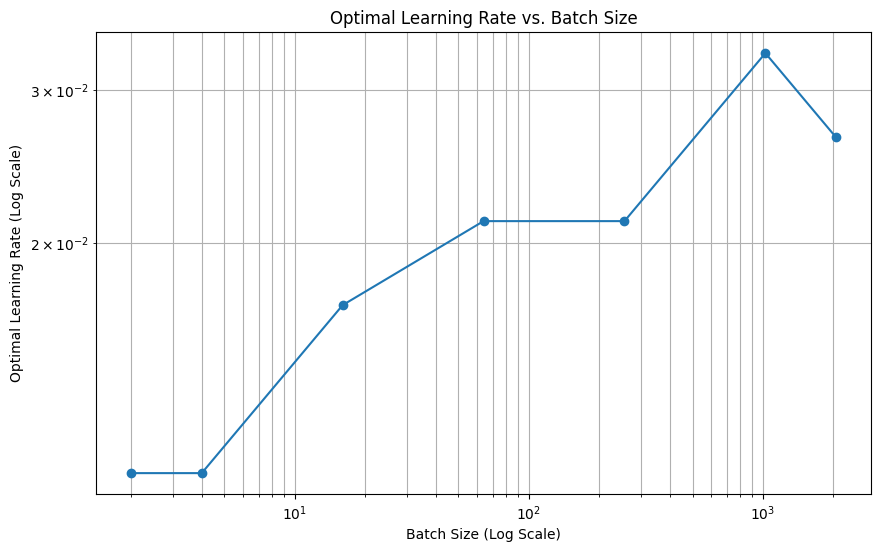

Optimal Learning Rates per Batch Size:
Batch Size: 2, Optimal LR: 0.010842, Min MSE (clipped): 28.04
Batch Size: 4, Optimal LR: 0.010842, Min MSE (clipped): 26.74
Batch Size: 16, Optimal LR: 0.016941, Min MSE (clipped): 25.49
Batch Size: 64, Optimal LR: 0.021176, Min MSE (clipped): 25.22
Batch Size: 256, Optimal LR: 0.021176, Min MSE (clipped): 25.14
Batch Size: 1024, Optimal LR: 0.033087, Min MSE (clipped): 25.09
Batch Size: 2048, Optimal LR: 0.026470, Min MSE (clipped): 25.09


In [6]:
batch_sizes = [2, 4, 16, 64, 256, 1024, 2048]

# Learning rate sweep
start_lr = 0.0001  # Starting LR
lr_factor = 1.25
num_lrs = 35  # Number of learning rates to sweep over
learning_rates = [start_lr * (lr_factor ** i) for i in range(num_lrs)]

# Store results
results = {}
optimal_lrs = []
min_final_mses = []

# Ceiling for loss values to handle divergence during plotting
loss_ceiling = 1000.0

for bs in batch_sizes:
    print(f"Running for batch size: {bs}")
    final_test_mses_for_bs = []
    for lr in learning_rates:
        # Run SGD for current batch size and learning rate
        _, _, test_sgd_mse = run_sgd(iters=100, batch_size=bs, lr=lr)
        # Get the final test MSE and clip it
        final_mse = min(test_sgd_mse[-1], loss_ceiling)
        final_test_mses_for_bs.append(final_mse)
    results[bs] = final_test_mses_for_bs

    # Find the optimal LR for this batch size (minimum MSE)
    min_mse_idx = np.argmin(final_test_mses_for_bs)
    optimal_lrs.append(learning_rates[min_mse_idx])
    min_final_mses.append(final_test_mses_for_bs[min_mse_idx])


# Plotting learning rates vs. final test MSE for each batch size
plt.figure(figsize=(12, 8))
for bs, mses in results.items():
    # Subtract sigma**2 and ensure values are positive for log scale
    plot_mses = [max(0.1, mse - sigma**2) for mse in mses]
    plt.plot(learning_rates, plot_mses, label=f'Batch Size: {bs}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Learning Rate')
plt.ylabel(r'Final Test Squared Error - $\sigma^2$ (Log Scale)')
plt.title('Final Test MSE vs. Learning Rate for different Batch Sizes')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# Plotting optimal learning rate vs. batch size
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, optimal_lrs, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Batch Size (Log Scale)')
plt.ylabel('Optimal Learning Rate (Log Scale)')
plt.title('Optimal Learning Rate vs. Batch Size')
plt.grid(True, which="both", ls="-")
plt.show()

print("Optimal Learning Rates per Batch Size:")
for i, bs in enumerate(batch_sizes):
    print(f"Batch Size: {bs}, Optimal LR: {optimal_lrs[i]:.6f}, Min MSE (clipped): {min_final_mses[i]:.2f}")


## Q2: MLP with SGD

We will now repeat a similar study, using a two-layer MLP rather than a linear regression. Again, conduct a sweep on the relationship between batch size and optimal learning rate. How does this relationship compare to the optimum for least-squares SGD?

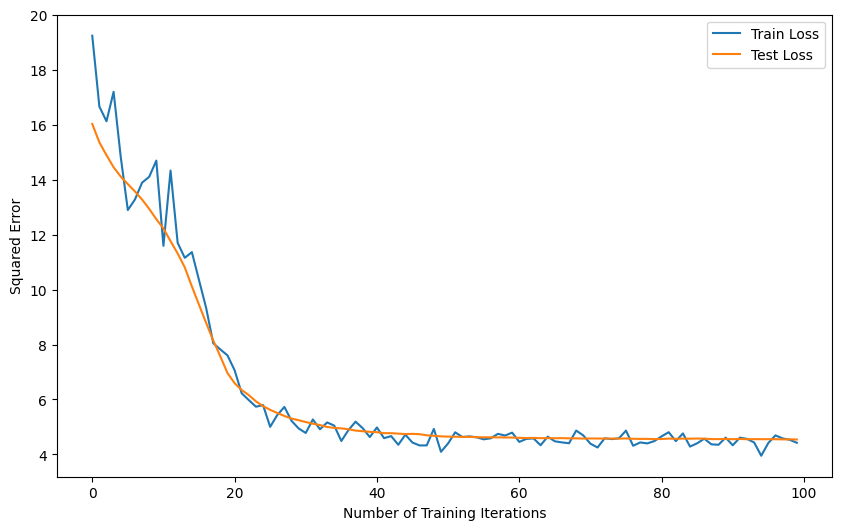

In [8]:
N = 10000 # number of data samples
D = 4  # input dimension
sigma = 2 # noise std

np.random.seed(0)
X_train = np.random.randn(10_000,D) # gaussian inputs for training data
X_test = np.random.randn(1_000,D) # gaussian inputs for test data
W1_true = np.random.randn(D,D) # ground truth weight
W2_true = np.random.randn(D,D) # ground truth weight
y_train = np.maximum(0, X_train @ W1_true) @ W2_true + sigma * np.random.randn(10_000,D) # noisy outputs training data
y_test = np.maximum(0, X_test @ W1_true) @ W2_true + sigma * np.random.randn(1_000,D) # noisy outputs test data

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

def model_inst(D):
    model = torch.nn.Sequential(
        torch.nn.Linear(D, D),
        torch.nn.ReLU(),
        torch.nn.Linear(D, D)
    )

    loss_fn = torch.nn.MSELoss()
    return model, loss_fn

def train_mlp_sgd(iters, batch_size, lr, opt='SGD'):
    torch.manual_seed(0)
    np.random.seed(0)
    model, loss_fn = model_inst(D)
    if opt == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        scheduler = None
    elif opt == 'Adam':
        # TODO
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.5), weight_decay=0.01)
        scheduler1 = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.001, end_factor=1.0, total_iters=10)
        scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters-10)
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[scheduler1, scheduler2],
            milestones=[10],
        )
        #
    else:
        raise ValueError("Optimizer not recognized")

    test_sgd_mse = []
    train_sgd_mse = []

    for i in range(iters):
        idx = np.random.randint(0, N, batch_size)
        x = torch.tensor(X_train[idx], dtype=torch.float32)
        y = torch.tensor(y_train[idx], dtype=torch.float32)

        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        test_sgd_mse.append(loss_fn(model(X_test), y_test).item())
        train_sgd_mse.append(loss_fn(model(x), y).item())

    return train_sgd_mse, test_sgd_mse

mlp_train_mse, mlp_test_mse = train_mlp_sgd(iters=100, batch_size=256, lr=0.1)

plt.figure(figsize=(10, 6))
plt.plot(mlp_train_mse, label='Train Loss')
plt.plot(mlp_test_mse, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel('Squared Error')
plt.legend()

Again, let's plot on log-linear scale minus the offset. Notice that the MLP converges to $\approx \sigma^2 + 0.57$ as opposed to $\sigma^2$.

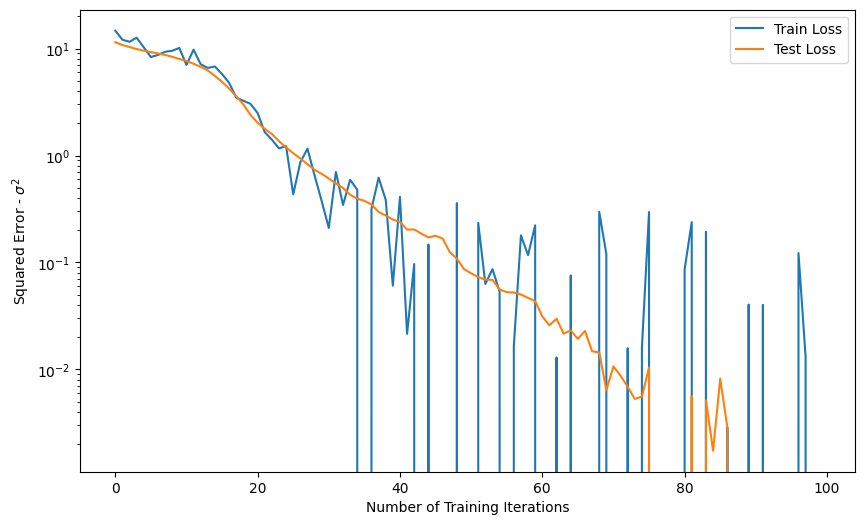

In [9]:
eps = 0.57
mlp_train_mse_res = [mse - (sigma**2 + eps) for mse in mlp_train_mse]
mlp_test_mse_res = [mse - (sigma**2 + eps) for mse in mlp_test_mse]

plt.figure(figsize=(10, 6))
plt.plot(mlp_train_mse_res, label='Train Loss')
plt.plot(mlp_test_mse_res, label='Test Loss')
plt.xlabel('Number of Training Iterations')
plt.ylabel(r'Squared Error - $\sigma^2$')
plt.yscale('log')
plt.legend()

Running MLP for batch size: 2
Running MLP for batch size: 4
Running MLP for batch size: 16
Running MLP for batch size: 64
Running MLP for batch size: 256
Running MLP for batch size: 1024
Running MLP for batch size: 2048


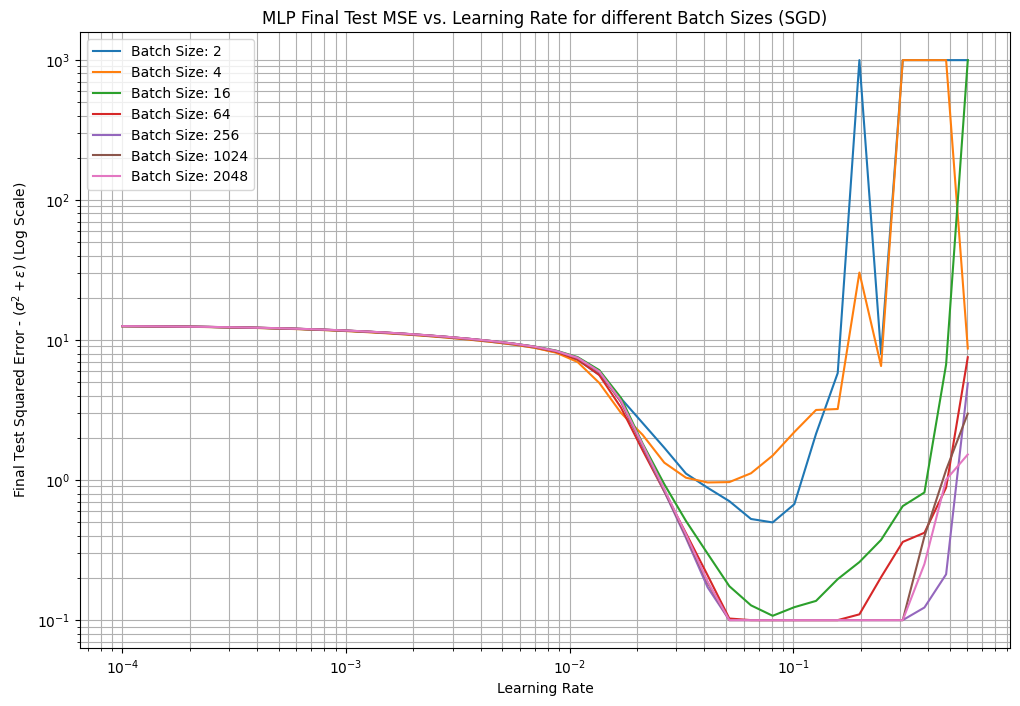

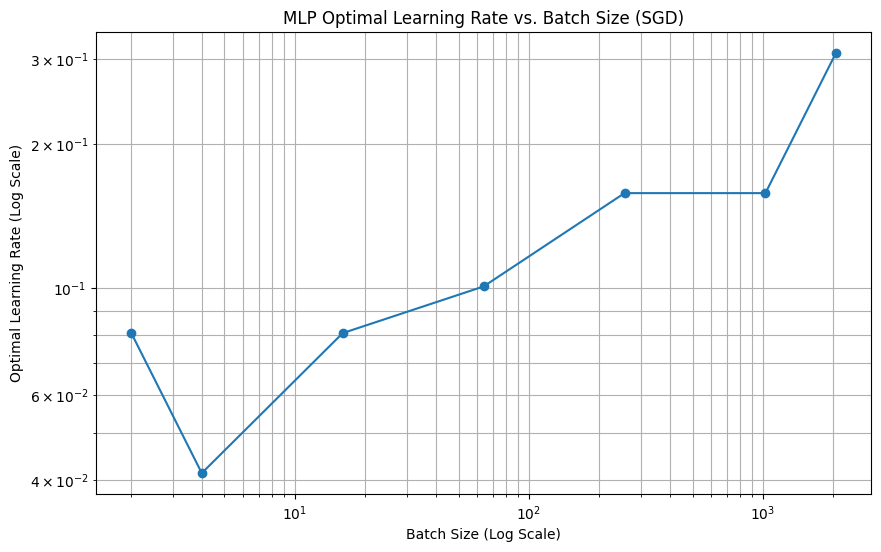

MLP Optimal Learning Rates per Batch Size (SGD):
Batch Size: 2, Optimal LR: 0.080779, Min MSE (clipped): 5.07
Batch Size: 4, Optimal LR: 0.041359, Min MSE (clipped): 5.53
Batch Size: 16, Optimal LR: 0.080779, Min MSE (clipped): 4.68
Batch Size: 64, Optimal LR: 0.100974, Min MSE (clipped): 4.60
Batch Size: 256, Optimal LR: 0.157772, Min MSE (clipped): 4.53
Batch Size: 1024, Optimal LR: 0.157772, Min MSE (clipped): 4.55
Batch Size: 2048, Optimal LR: 0.308149, Min MSE (clipped): 4.53


In [12]:
batch_sizes_mlp = [2, 4, 16, 64, 256, 1024, 2048]

# Learning rate sweep (potentially wider range for MLP)
start_lr_mlp = 0.0001
lr_factor_mlp = 1.25
num_lrs_mlp = 40 # Increased number of LRs to cover a wider range
learning_rates_mlp = [start_lr_mlp * (lr_factor_mlp ** i) for i in range(num_lrs_mlp)]

# Store results
results_mlp = {}
optimal_lrs_mlp = []
min_final_mses_mlp = []

# Ceiling for loss values to handle divergence during plotting
loss_ceiling_mlp = 1000.0

for bs in batch_sizes_mlp:
    print(f"Running MLP for batch size: {bs}")
    final_test_mses_for_bs_mlp = []
    for lr in learning_rates_mlp:
        # Run MLP training for current batch size and learning rate
        _, mlp_test_mse = train_mlp_sgd(iters=100, batch_size=bs, lr=lr, opt='SGD')
        # Get the final test MSE and clip it
        final = mlp_test_mse[-1]
        if not np.isfinite(final):
            final = loss_ceiling_mlp
        final = min(final, loss_ceiling_mlp)
        final_test_mses_for_bs_mlp.append(final)

    results_mlp[bs] = final_test_mses_for_bs_mlp

    # Find the optimal LR for this batch size (minimum MSE)
    min_mse_idx_mlp = np.argmin(final_test_mses_for_bs_mlp)
    optimal_lrs_mlp.append(learning_rates_mlp[min_mse_idx_mlp])
    min_final_mses_mlp.append(final_test_mses_for_bs_mlp[min_mse_idx_mlp])


# Plotting learning rates vs. final test MSE for each batch size (MLP)
plt.figure(figsize=(12, 8))
for bs, mses in results_mlp.items():
    # Subtract sigma**2 + eps and ensure values are positive for log scale
    plot_mses_mlp = [max(0.1, mse - (sigma**2 + eps)) for mse in mses]
    plt.plot(learning_rates_mlp, plot_mses_mlp, label=f'Batch Size: {bs}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Learning Rate')
plt.ylabel(r'Final Test Squared Error - $(\sigma^2 + \epsilon)$ (Log Scale)')
plt.title('MLP Final Test MSE vs. Learning Rate for different Batch Sizes (SGD)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# Plotting optimal learning rate vs. batch size (MLP)
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes_mlp, optimal_lrs_mlp, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Batch Size (Log Scale)')
plt.ylabel('Optimal Learning Rate (Log Scale)')
plt.title('MLP Optimal Learning Rate vs. Batch Size (SGD)')
plt.grid(True, which="both", ls="-")
plt.show()

print("MLP Optimal Learning Rates per Batch Size (SGD):")
for i, bs in enumerate(batch_sizes_mlp):
    print(f"Batch Size: {bs}, Optimal LR: {optimal_lrs_mlp[i]:.6f}, Min MSE (clipped): {min_final_mses_mlp[i]:.2f}")


#### Q3: MLP with Adam.

Finally, we will repeat the scaling law curve, but using the Adam optimizer. This time, implement a learning rate schedule, such that the learning rate has a linear warmup for 10 steps, then uses cosine decay for the rest of training. Use a beta1=0.5, beta2=0.5, and a weight decay of 0.001. As before, plot the comparison curves, then plot a curve of the batch size vs. optimal learning rate. Does the scaling for learning rate change with Adam vs. SGD?

Running MLP with Adam for batch size: 2
Running MLP with Adam for batch size: 4
Running MLP with Adam for batch size: 16
Running MLP with Adam for batch size: 64
Running MLP with Adam for batch size: 256
Running MLP with Adam for batch size: 1024
Running MLP with Adam for batch size: 2048


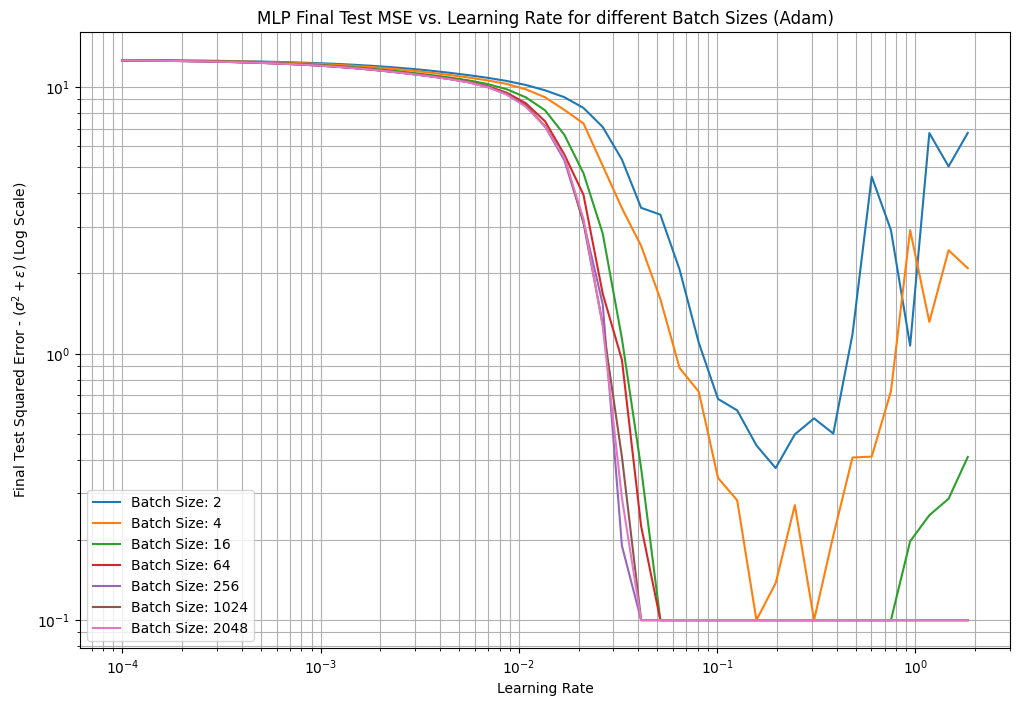

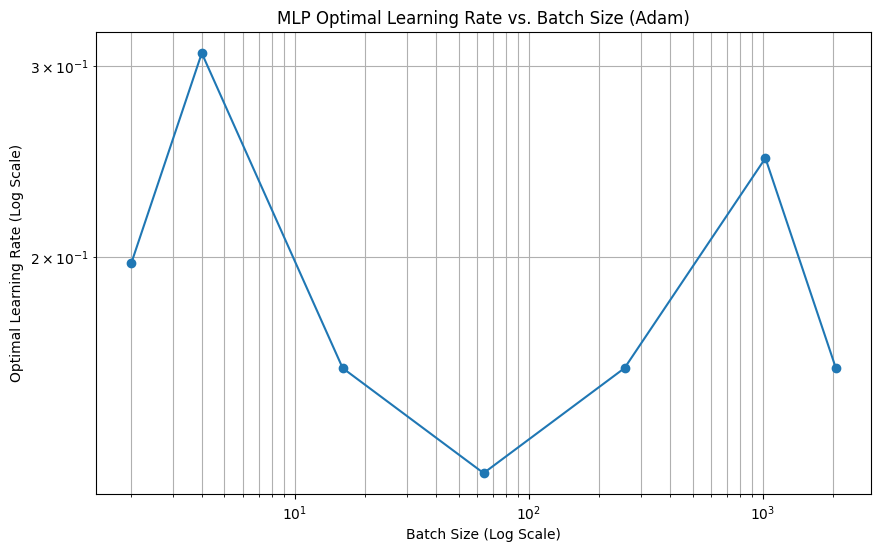

MLP Optimal Learning Rates per Batch Size (Adam):
Batch Size: 2, Optimal LR: 0.197215, Min MSE (clipped): 4.94
Batch Size: 4, Optimal LR: 0.308149, Min MSE (clipped): 4.53
Batch Size: 16, Optimal LR: 0.157772, Min MSE (clipped): 4.27
Batch Size: 64, Optimal LR: 0.126218, Min MSE (clipped): 4.12
Batch Size: 256, Optimal LR: 0.157772, Min MSE (clipped): 4.10
Batch Size: 1024, Optimal LR: 0.246519, Min MSE (clipped): 4.10
Batch Size: 2048, Optimal LR: 0.157772, Min MSE (clipped): 4.10


In [14]:
batch_sizes_adam = [2, 4, 16, 64, 256, 1024, 2048]

# Learning rate sweep (potentially wider range for Adam)
start_lr_adam = 0.0001 # Start with a small LR
lr_factor_adam = 1.25
num_lrs_adam = 45 # Potentially more LRs to cover Adam's behavior
learning_rates_adam = [start_lr_adam * (lr_factor_adam ** i) for i in range(num_lrs_adam)]

# Store results
results_adam = {}
optimal_lrs_adam = []
min_final_mses_adam = []

# Ceiling for loss values to handle divergence during plotting
loss_ceiling_adam = 1000.0

for bs in batch_sizes_adam:
    print(f"Running MLP with Adam for batch size: {bs}")
    final_test_mses_for_bs_adam = []
    for lr in learning_rates_adam:
        _, mlp_test_mse_adam = train_mlp_sgd(iters=100, batch_size=bs, lr=lr, opt='Adam')

        final = float(mlp_test_mse_adam[-1])
        if not np.isfinite(final):
            final = loss_ceiling_adam
        final = min(final, loss_ceiling_adam)

        final_test_mses_for_bs_adam.append(final)

    results_adam[bs] = final_test_mses_for_bs_adam
    mses_arr = np.array(final_test_mses_for_bs_adam, dtype=float)

    if np.all(mses_arr >= loss_ceiling_adam - 1e-12):
        min_mse_idx_adam = 0
        print(f"Warning: All losses for BS {bs} hit the ceiling. Optimal LR might not be accurate.")
    else:
        min_mse_idx_adam = int(np.argmin(mses_arr))


    optimal_lrs_adam.append(learning_rates_adam[min_mse_idx_adam])
    min_final_mses_adam.append(final_test_mses_for_bs_adam[min_mse_idx_adam])


# Plotting learning rates vs. final test MSE for each batch size (MLP Adam)
plt.figure(figsize=(12, 8))
for bs, mses in results_adam.items():
    # Subtract sigma**2 + eps and ensure values are positive for log scale
    # Use a small value if mse - (sigma**2 + eps) is non-positive for log plotting
    plot_mses_adam = [max(0.1, mse - (sigma**2 + eps)) for mse in mses]
    plt.plot(learning_rates_adam, plot_mses_adam, label=f'Batch Size: {bs}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Learning Rate')
plt.ylabel(r'Final Test Squared Error - $(\sigma^2 + \epsilon)$ (Log Scale)')
plt.title('MLP Final Test MSE vs. Learning Rate for different Batch Sizes (Adam)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# Plotting optimal learning rate vs. batch size (MLP Adam)
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes_adam, optimal_lrs_adam, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Batch Size (Log Scale)')
plt.ylabel('Optimal Learning Rate (Log Scale)')
plt.title('MLP Optimal Learning Rate vs. Batch Size (Adam)')
plt.grid(True, which="both", ls="-")
plt.show()

print("MLP Optimal Learning Rates per Batch Size (Adam):")
for i, bs in enumerate(batch_sizes_adam):
    print(f"Batch Size: {bs}, Optimal LR: {optimal_lrs_adam[i]:.6f}, Min MSE (clipped): {min_final_mses_adam[i]:.2f}")